In [1]:
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('monthly_sales_dataset.csv')

In [3]:
df.head()

,Month,Sales
0,2018-01-31,193.00
1,2018-02-28,216.53
2,2018-03-31,234.72
3,2018-04-30,236.10
4,2018-05-31,235.79


In [4]:
df.tail()

,Month,Sales
55,2022-08-31,298.36
56,2022-09-30,294.25
57,2022-10-31,293.93
58,2022-11-30,302.32
59,2022-12-31,305.50


<Axes: >

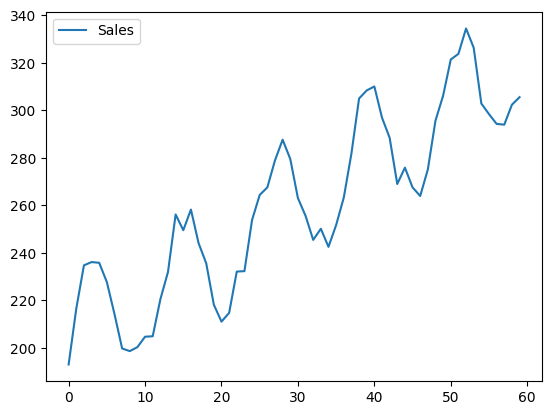

In [5]:
df.plot()

In [6]:
df.columns = ['ds','y']
df.head()

,ds,y
0,2018-01-31,193.00
1,2018-02-28,216.53
2,2018-03-31,234.72
3,2018-04-30,236.10
4,2018-05-31,235.79


In [7]:
df['ds'] = pd.to_datetime(df['ds'])

In [8]:
df.head()

,ds,y
0,2018-01-31,193.00
1,2018-02-28,216.53
2,2018-03-31,234.72
3,2018-04-30,236.10
4,2018-05-31,235.79


In [9]:
df.tail()

,ds,y
55,2022-08-31,298.36
56,2022-09-30,294.25
57,2022-10-31,293.93
58,2022-11-30,302.32
59,2022-12-31,305.50


In [10]:
# Initialize the Model
model=Prophet()

In [11]:
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,2018-01-31,193.00
1,2018-02-28,216.53
2,2018-03-31,234.72
3,2018-04-30,236.10
4,2018-05-31,235.79


In [12]:
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [13]:
future_dates=model.make_future_dataframe(periods=24)

In [14]:
future_dates.head()

,ds
0,2018-01-31
1,2018-02-28
2,2018-03-31
3,2018-04-30
4,2018-05-31


In [15]:
future_dates.tail()

,ds
79,2023-01-20
80,2023-01-21
81,2023-01-22
82,2023-01-23
83,2023-01-24


In [16]:
prediction=model.predict(future_dates)

In [17]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-31,205.252013,193.957591,203.199368,205.252013,205.252013,-6.565234,-6.565234,-6.565234,-6.565234,-6.565234,-6.565234,0.0,0.0,0.0,198.686779
1,2018-02-28,206.880739,207.628356,216.794256,206.880739,206.880739,5.330611,5.330611,5.330611,5.330611,5.330611,5.330611,0.0,0.0,0.0,212.211349
2,2018-03-31,208.683971,227.175975,236.449848,208.683971,208.683971,23.018451,23.018451,23.018451,23.018451,23.018451,23.018451,0.0,0.0,0.0,231.702422
3,2018-04-30,210.429034,227.720105,237.095143,210.429034,210.429034,22.027051,22.027051,22.027051,22.027051,22.027051,22.027051,0.0,0.0,0.0,232.456085
4,2018-05-31,212.232266,234.310810,243.728832,212.232266,212.232266,26.638759,26.638759,26.638759,26.638759,26.638759,26.638759,0.0,0.0,0.0,238.871025


In [18]:
prediction[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
79,2023-01-20,330.949115,326.032801,335.307132
80,2023-01-21,333.795003,329.058126,338.558923
81,2023-01-22,336.196344,331.752642,341.023190
82,2023-01-23,338.008597,333.590235,342.677149
83,2023-01-24,339.094585,334.394217,343.661366


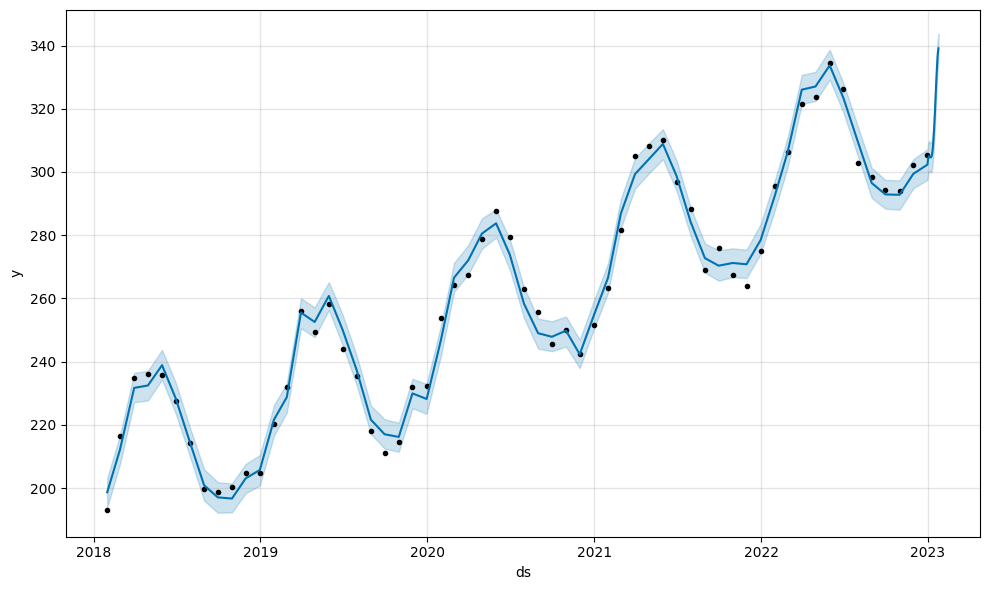

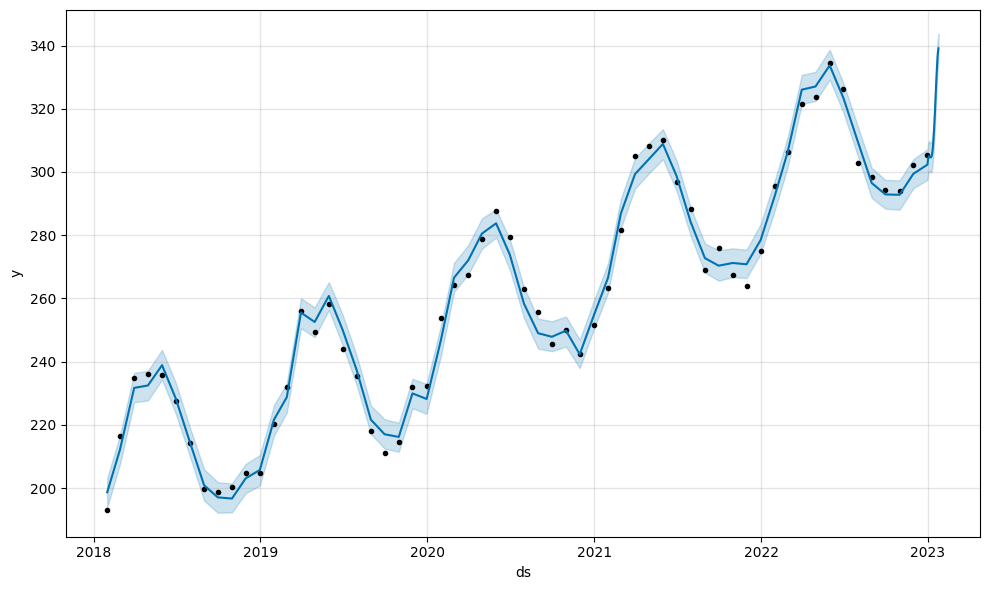

In [19]:
model.plot(prediction)

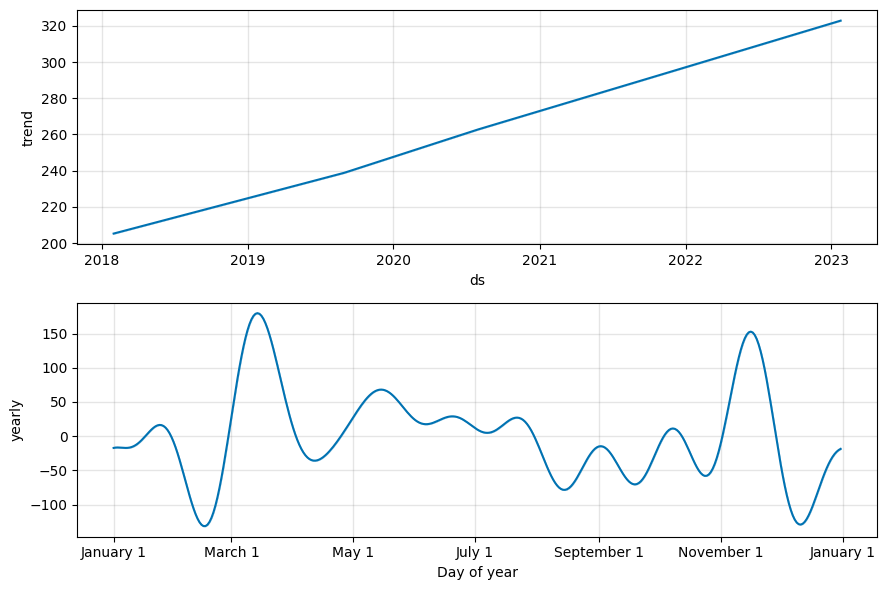

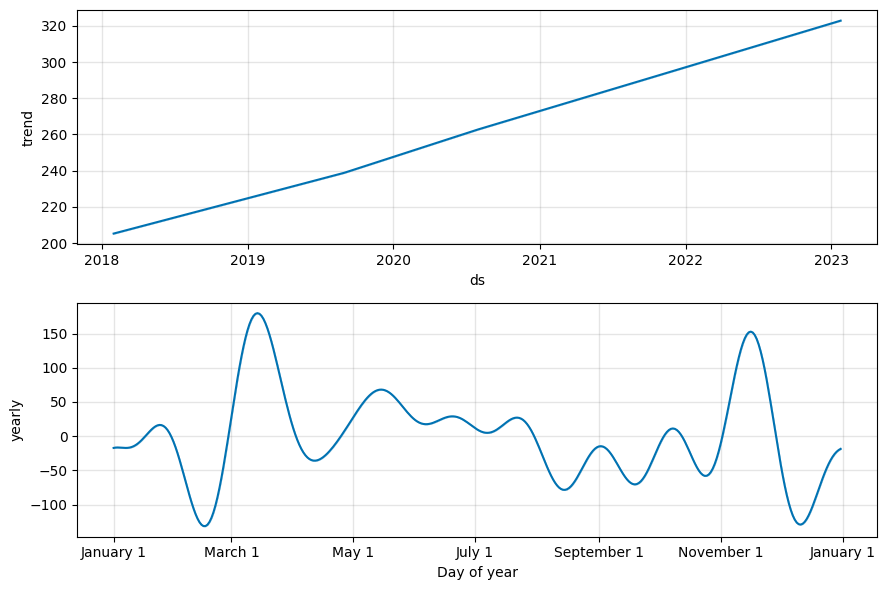

In [20]:
model.plot_components(prediction)